<a href="https://colab.research.google.com/github/farahnda/Learning/blob/main/Overfitting_and_Underfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_classification
# buat dataset custom
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot

In [2]:
X, y = make_classification(n_samples = 9000, n_features=18, n_informative = 4, n_redundant = 12, random_state = 4)
# jumlah data = 9000, jumlah kolom fitur = 18 (nama, lahir, etc), fitur berpengaruh = 4 (gaji, umur), fitur hasil kombinasi fitur lain = 12 (tinggi, tinggi cm),

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [4]:
train_scores, test_scores = list(), list()

In [5]:
values = [i for i in range(1, 21)]

In [6]:
for i in values:
  model = DecisionTreeClassifier(max_depth = i)
  model.fit(X_train, y_train)
  train_yhat = model.predict(X_train)
  train_acc = accuracy_score(y_train, train_yhat)
  test_yhat = model.predict(X_test)
  test_acc = accuracy_score(y_test, test_yhat)
  train_scores.append(train_acc)
  test_scores.append(test_acc)
  print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>1, train: 0.837, test: 0.835
>2, train: 0.851, test: 0.850
>3, train: 0.868, test: 0.864
>4, train: 0.900, test: 0.885
>5, train: 0.920, test: 0.902
>6, train: 0.934, test: 0.913
>7, train: 0.964, test: 0.931
>8, train: 0.974, test: 0.938
>9, train: 0.979, test: 0.936
>10, train: 0.987, test: 0.943
>11, train: 0.991, test: 0.941
>12, train: 0.993, test: 0.940
>13, train: 0.995, test: 0.935
>14, train: 0.996, test: 0.938
>15, train: 0.997, test: 0.940
>16, train: 0.998, test: 0.941
>17, train: 0.999, test: 0.939
>18, train: 1.000, test: 0.937
>19, train: 1.000, test: 0.937
>20, train: 1.000, test: 0.937


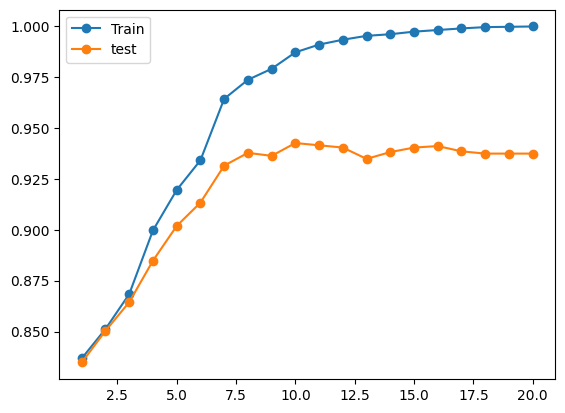

In [7]:
pyplot.plot(values, train_scores, '-o', label='Train')
pyplot.plot(values, test_scores, '-o', label='test')
pyplot.legend()
pyplot.show()

In [8]:
from sklearn.model_selection import GridSearchCV

In [9]:
param_grid = {'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, 6, 10, 20], 'min_samples_split': [5, 10, 20, 50, 100]}
clf = GridSearchCV(DecisionTreeClassifier(), param_grid, cv = 3, n_jobs = -1, scoring = 'accuracy')
clf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 10, 20],
                         'min_samples_split': [5, 10, 20, 50, 100]},
             scoring='accuracy')

In [10]:
GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 10, 20],
                         'min_samples_split': [5, 10, 20, 50, 100]},
             scoring='accuracy')

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 10, 20],
                         'min_samples_split': [5, 10, 20, 50, 100]},
             scoring='accuracy')

In [11]:
clf.best_estimator_

DecisionTreeClassifier(max_depth=20, min_samples_split=20)

In [12]:
DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=5)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=5)

In [13]:
print(accuracy_score(y_train, clf.predict(X_train)))
print(accuracy_score(y_test, clf.predict(X_test)))

0.98
0.94
